- vanilla retriever only returns similar searches meaning repeated information
- with MMR we can get different results which are not similar to get more information & more perspective of the same query
- ideally we want output to be relevant and also not redundant

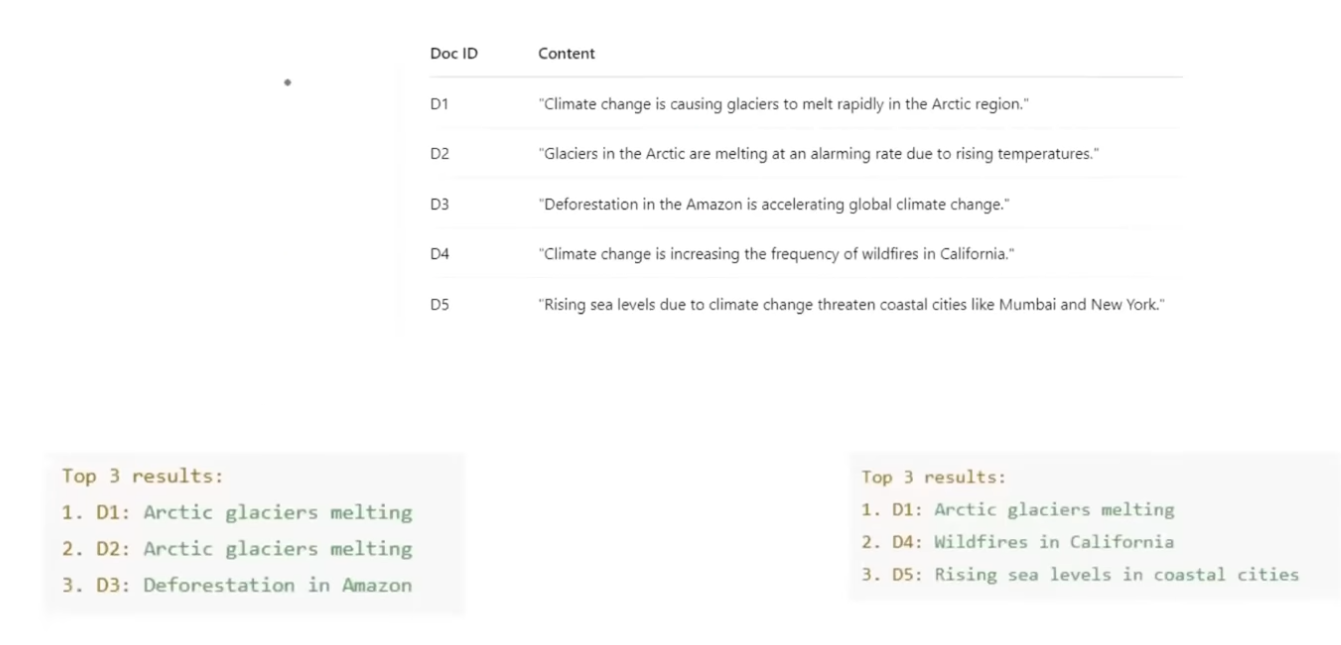

In [1]:
from langchain_core.documents import Document

# Sample documents
docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content="LangChain supports Chroma, FAISS, Pinecone, and more."),
]

In [10]:
# %pip install faiss-cpu

In [6]:
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

# Initialize OpenAI embeddings
embedding_model = OpenAIEmbeddings()

# Step 2: Create the FAISS vector store from documents
vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embedding_model
)

In [7]:
#enable mmr in retriever
retriever = vectorstore.as_retriever(
    search_type='mmr',
    search_kwargs={'k':3, 'lambda_mult':1}  #k=top results, lambda_mult=relevance-diversity balance
)

In [8]:
query = 'whats langchain'
results = retriever.invoke(query)

In [9]:
for i , doc in enumerate(results):
    print(f"--result: {i+1}--")
    print(f"content: {doc.page_content}")

--result: 1--
content: LangChain is used to build LLM based applications.
--result: 2--
content: LangChain makes it easy to work with LLMs.
--result: 3--
content: LangChain supports Chroma, FAISS, Pinecone, and more.
